# Softmax 模型拟合结果

本笔记本展示 softmax 模型对人类 region 选择行为的拟合结果，包括：
- 参数估计汇总表
- 参数对比柱状图
- 每 Round 的 Log-Likelihood 与准确率
- Softmax 概率热力图
- 人类 vs Agent 选择序列对比

In [82]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba, Normalize
from matplotlib import cm
from scipy.special import logsumexp
from collections import defaultdict
import math
import glob as glob_module

# 导入 fit_softmax.py 中的工具函数
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from fit_softmax import (
    ROWS, COLS, NUM_COLORS, ROUND_SIZES, ROUND_SEEDS,
    PRACTICE_SIZES, PRACTICE_SEEDS,
    mulberry32, generate_map, centroid_distance,
    build_all_maps, parse_csv, build_fitting_steps,
    fit_participant, compute_utilities, is_color_legal,
    count_effective_colors, neg_log_likelihood,
)

# 颜色与 App.tsx 保持一致
COLORS = ['#377eb8', '#4daf4a', '#984ea3', '#ffff33']  # Blue, Green, Purple, Yellow (Set1)
COLOR_NAMES = ['Blue', 'Green', 'Purple', 'Yellow']
UNCOLORED = '#e0e0e0'

# 中文字体配置
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'STHeiti', 'Arial Unicode MS']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
else:
    plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

print('导入完成')

导入完成


## 1. 数据加载 & 拟合

In [83]:
# 预生成所有地图
maps = build_all_maps()

# 加载所有被试数据
data_dir = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'data'))
csv_files = sorted(glob_module.glob(os.path.join(data_dir, 'data_*.csv')))
print(f'数据目录: {data_dir}')
print(f'找到 {len(csv_files)} 个被试文件')

数据目录: /Users/akira1/Documents/26春/codes/grid-puzzle-experiment-main/model code/data
找到 7 个被试文件


In [84]:
# 运行拟合
all_results = []
for filepath in csv_files:
    name = os.path.basename(filepath).replace('data_', '').replace('.csv', '')
    result = fit_participant(filepath, maps)
    if result is not None:
        result['name'] = name
        all_results.append(result)
        print(f'{name}: beta_n={result["beta_n"]:.4f}, beta_d={result["beta_d"]:.4f}, '
              f'LL={result["log_likelihood"]:.2f}, acc={result["accuracy"]:.1%}')

print(f'\n共拟合 {len(all_results)} 个被试')

031: beta_n=0.3130, beta_d=-0.0449, LL=-1266.01, acc=25.2%
Rex: beta_n=1.1605, beta_d=0.0347, LL=-839.62, acc=32.9%
cmf: beta_n=1.6417, beta_d=-0.1685, LL=-657.39, acc=47.7%
qhw: beta_n=1.2100, beta_d=-0.2139, LL=-824.25, acc=40.5%
yyq: beta_n=1.2532, beta_d=0.2221, LL=-738.38, acc=43.6%
杨田印盈: beta_n=0.5152, beta_d=0.3399, LL=-891.80, acc=25.9%
程子健: beta_n=-0.1653, beta_d=-0.0764, LL=-1040.62, acc=18.5%

共拟合 7 个被试


## 2. 结果汇总表

使用 Canonical Color Normalization：未使用过的合法颜色视为等价，有效颜色数 = 已使用且合法的颜色数 + (1 if 存在未使用且合法的颜色)。

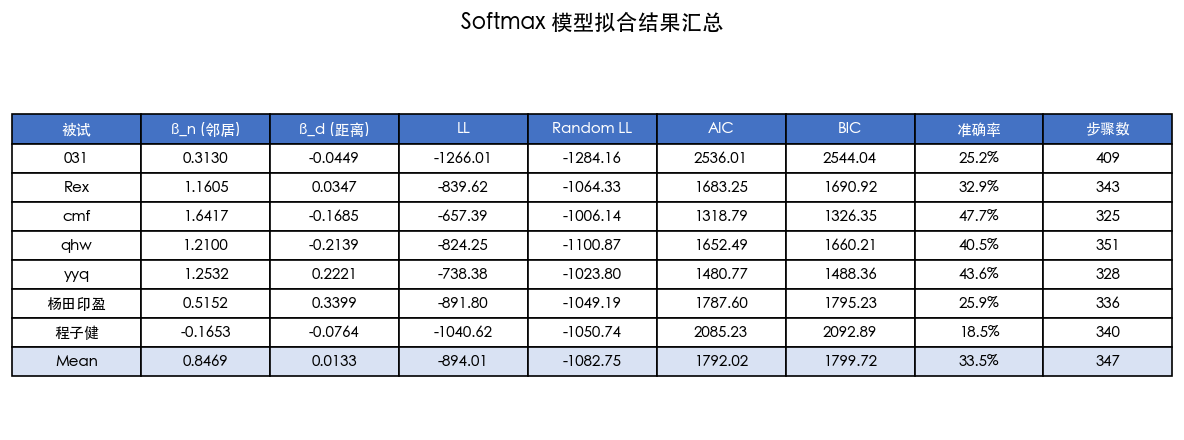

In [85]:
# 汇总表
fig, ax = plt.subplots(figsize=(10, 1.0 + 0.4 * len(all_results)))
ax.axis('off')

columns = ['被试', 'β_n (邻居)', 'β_d (距离)', 'LL', 'Random LL', 'AIC', 'BIC', '准确率', '步骤数']
cell_text = []
for r in all_results:
    cell_text.append([
        r['name'],
        f"{r['beta_n']:.4f}",
        f"{r['beta_d']:.4f}",
        f"{r['log_likelihood']:.2f}",
        f"{r['random_ll']:.2f}",
        f"{r['aic']:.2f}",
        f"{r['bic']:.2f}",
        f"{r['accuracy']:.1%}",
        str(r['n_steps']),
    ])

# 添加均值行
if len(all_results) > 1:
    cell_text.append([
        'Mean',
        f"{np.mean([r['beta_n'] for r in all_results]):.4f}",
        f"{np.mean([r['beta_d'] for r in all_results]):.4f}",
        f"{np.mean([r['log_likelihood'] for r in all_results]):.2f}",
        f"{np.mean([r['random_ll'] for r in all_results]):.2f}",
        f"{np.mean([r['aic'] for r in all_results]):.2f}",
        f"{np.mean([r['bic'] for r in all_results]):.2f}",
        f"{np.mean([r['accuracy'] for r in all_results]):.1%}",
        f"{np.mean([r['n_steps'] for r in all_results]):.0f}",
    ])

table = ax.table(cellText=cell_text, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.4)

# 表头样式
for j in range(len(columns)):
    table[0, j].set_facecolor('#4472C4')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 均值行样式
if len(all_results) > 1:
    for j in range(len(columns)):
        table[len(cell_text), j].set_facecolor('#D9E2F3')
        table[len(cell_text), j].set_text_props(fontweight='bold')

ax.set_title('Softmax 模型拟合结果汇总', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. 图1: 参数对比柱状图

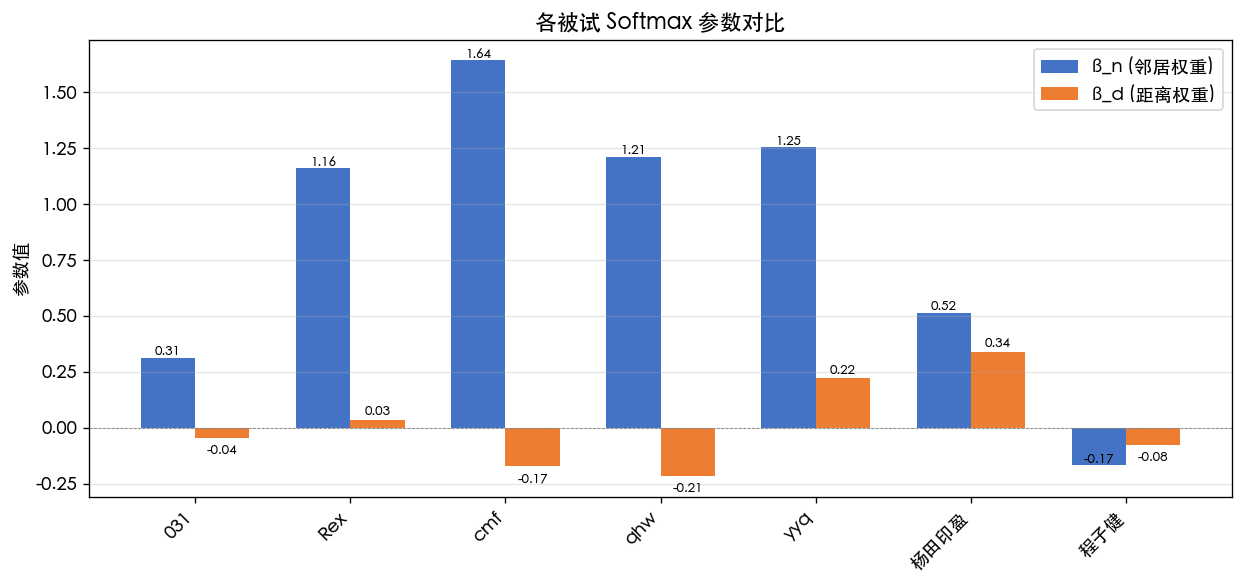

In [86]:
names = [r['name'] for r in all_results]
beta_ns = [r['beta_n'] for r in all_results]
beta_ds = [r['beta_d'] for r in all_results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(max(6, len(names) * 1.5), 5))
bars1 = ax.bar(x - width/2, beta_ns, width, label='β_n (邻居权重)', color='#4472C4')
bars2 = ax.bar(x + width/2, beta_ds, width, label='β_d (距离权重)', color='#ED7D31')

ax.set_ylabel('参数值')
ax.set_title('各被试 Softmax 参数对比')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# 数值标注
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.01 if h >= 0 else -0.03),
            f'{h:.2f}', ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

## 4. 图2: 每 Round 的 Log-Likelihood 对比

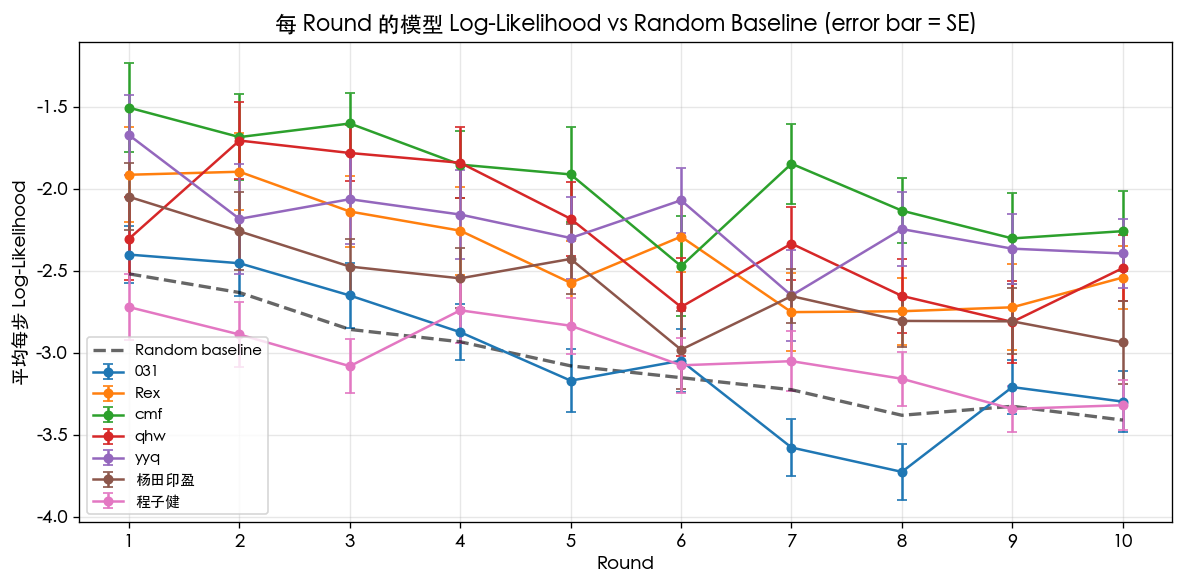

In [87]:
round_labels = [str(i+1) for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.tab10

# 需要重新计算每个被试每个 round 内各步的 LL，以获得 step-level SE
def compute_step_lls(result, maps):
    """计算每个被试在每个 round 中每一步的 LL。"""
    actions = parse_csv(result['filepath'])
    fitting_steps = build_fitting_steps(actions, maps)
    params = np.array([result['beta_n'], result['beta_d']])
    
    round_step_lls = defaultdict(list)
    for step in fitting_steps:
        utilities = compute_utilities(
            step['uncolored'], step['regions'],
            step['adjacency'], step['current_colors'], params
        )
        chosen_idx = step['uncolored'].index(step['chosen_region'])
        log_p_region = utilities[chosen_idx] - logsumexp(utilities)
        log_p_color = -np.log(step['num_effective_colors'])
        round_step_lls[step['round']].append(log_p_region + log_p_color)
    
    # random baseline per step
    round_step_random = defaultdict(list)
    for step in fitting_steps:
        log_p = -np.log(len(step['uncolored'])) + (-np.log(step['num_effective_colors']))
        round_step_random[step['round']].append(log_p)
    
    return round_step_lls, round_step_random

# 每个被试一条线（带 error bar）
for idx, r in enumerate(all_results):
    step_lls, _ = compute_step_lls(r, maps)
    means, ses = [], []
    for rnd in round_labels:
        if rnd in step_lls and len(step_lls[rnd]) > 1:
            arr = np.array(step_lls[rnd])
            means.append(np.mean(arr))
            ses.append(np.std(arr, ddof=1) / np.sqrt(len(arr)))
        elif rnd in step_lls:
            means.append(np.mean(step_lls[rnd]))
            ses.append(0)
        else:
            means.append(np.nan)
            ses.append(0)
    means, ses = np.array(means), np.array(ses)
    ax.errorbar(round_labels, means, yerr=ses, fmt='o-', color=cmap(idx),
                label=r['name'], linewidth=1.5, markersize=5, capsize=3)

# Random baseline（取所有被试平均）
random_means = []
for rnd in round_labels:
    vals = []
    for r in all_results:
        _, step_random = compute_step_lls(r, maps)
        if rnd in step_random:
            vals.append(np.mean(step_random[rnd]))
    random_means.append(np.mean(vals) if vals else np.nan)

ax.plot(round_labels, random_means, 'k--', label='Random baseline', linewidth=2, alpha=0.6)

ax.set_xlabel('Round')
ax.set_ylabel('平均每步 Log-Likelihood')
ax.set_title('每 Round 的模型 Log-Likelihood vs Random Baseline (error bar = SE)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 图3: 每 Round 准确率对比

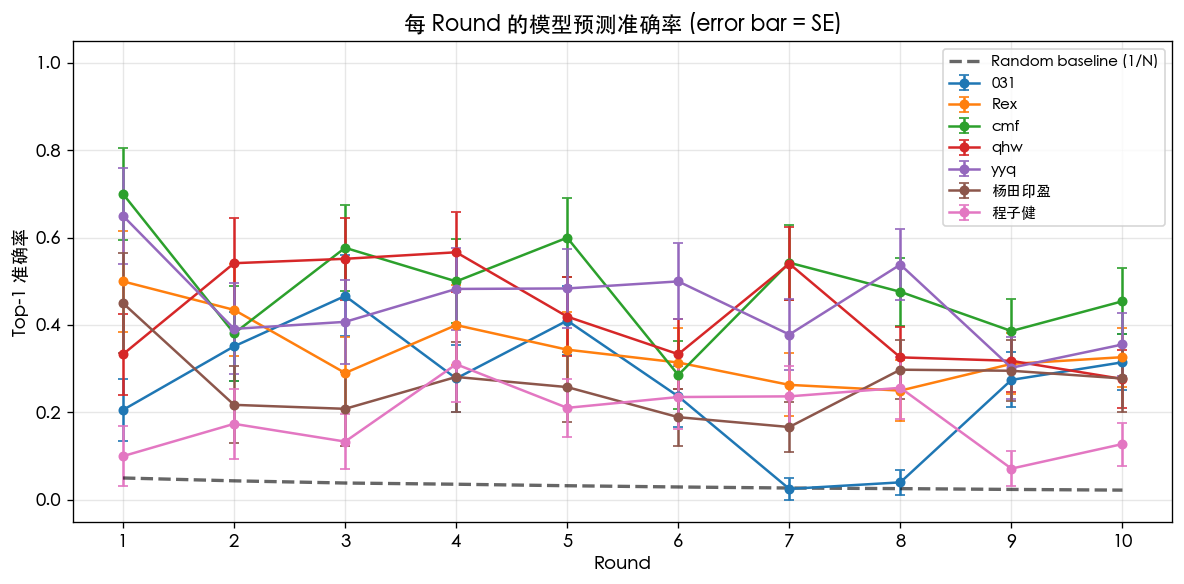

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))

def compute_step_accs(result, maps):
    """计算每个被试在每个 round 中每一步是否 top-1 命中。"""
    actions = parse_csv(result['filepath'])
    fitting_steps = build_fitting_steps(actions, maps)
    params = np.array([result['beta_n'], result['beta_d']])
    
    round_step_hits = defaultdict(list)  # 每步 1 or 0
    for step in fitting_steps:
        utilities = compute_utilities(
            step['uncolored'], step['regions'],
            step['adjacency'], step['current_colors'], params
        )
        chosen_idx = step['uncolored'].index(step['chosen_region'])
        hit = 1 if chosen_idx == np.argmax(utilities) else 0
        round_step_hits[step['round']].append(hit)
    return round_step_hits

for idx, r in enumerate(all_results):
    step_hits = compute_step_accs(r, maps)
    means, ses = [], []
    for rnd in round_labels:
        if rnd in step_hits and len(step_hits[rnd]) > 1:
            arr = np.array(step_hits[rnd], dtype=float)
            means.append(np.mean(arr))
            ses.append(np.std(arr, ddof=1) / np.sqrt(len(arr)))
        elif rnd in step_hits:
            means.append(np.mean(step_hits[rnd]))
            ses.append(0)
        else:
            means.append(np.nan)
            ses.append(0)
    means, ses = np.array(means), np.array(ses)
    ax.errorbar(round_labels, means, yerr=ses, fmt='o-', color=cmap(idx),
                label=r['name'], linewidth=1.5, markersize=5, capsize=3)

# Random baseline: 1/num_regions
random_accs = [1.0 / ROUND_SIZES[int(rnd) - 1] for rnd in round_labels]
ax.plot(round_labels, random_accs, 'k--', label='Random baseline (1/N)', linewidth=2, alpha=0.6)

ax.set_xlabel('Round')
ax.set_ylabel('Top-1 准确率')
ax.set_title('每 Round 的模型预测准确率 (error bar = SE)')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 图4: Softmax 概率热力图

选取某个被试的某个 round 中间阶段的几步（已有部分着色），展示模型在每步对各 region 的选择概率。灰色=已着色，热力图颜色=未着色region的选择概率，红框=人类实际选择。

In [89]:
def draw_grid_base(ax, grid, regions):
    """绘制 grid 基础结构（边界线和 region 标签）。"""
    for r in range(ROWS):
        for c in range(COLS):
            for dr, dc in [(0,1),(1,0)]:
                nr, nc = r+dr, c+dc
                if nr < ROWS and nc < COLS and grid[r][c] != grid[nr][nc]:
                    if dc == 1:
                        ax.plot([c+0.5, c+0.5], [r-0.5, r+0.5], color='#666', linewidth=0.5)
                    else:
                        ax.plot([c-0.5, c+0.5], [r+0.5, r+0.5], color='#666', linewidth=0.5)
    for i, cells in enumerate(regions):
        avg_r = sum(r for r, c in cells) / len(cells)
        avg_c = sum(c for r, c in cells) / len(cells)
        ax.text(avg_c, avg_r, str(i), ha='center', va='center', fontsize=5, color='#333')
    ax.set_xticks([])
    ax.set_yticks([])


def draw_highlight_border(ax, regions, chosen, color='red', linewidth=2.5):
    """在指定 region 周围绘制高亮边框。"""
    cells_set = set(regions[chosen])
    for (r, c) in regions[chosen]:
        for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
            nr, nc = r+dr, c+dc
            if (nr, nc) not in cells_set or nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS:
                if dc == 1:
                    ax.plot([c+0.5, c+0.5], [r-0.5, r+0.5], color=color, linewidth=linewidth)
                elif dc == -1:
                    ax.plot([c-0.5, c-0.5], [r-0.5, r+0.5], color=color, linewidth=linewidth)
                elif dr == 1:
                    ax.plot([c-0.5, c+0.5], [r+0.5, r+0.5], color=color, linewidth=linewidth)
                elif dr == -1:
                    ax.plot([c-0.5, c+0.5], [r-0.5, r-0.5], color=color, linewidth=linewidth)


def draw_softmax_heatmap(ax, grid, regions, step, params, title=''):
    """在 grid 上绘制 softmax 概率热力图，红框标出人类选择。"""
    uncolored = step['uncolored']
    utilities = compute_utilities(uncolored, step['regions'], step['adjacency'],
                                  step['current_colors'], params)
    log_probs = utilities - logsumexp(utilities)
    probs = np.exp(log_probs)

    # 构建 region -> prob 映射
    prob_map = {}
    for i, rid in enumerate(uncolored):
        prob_map[rid] = probs[i]

    # 绘制: 蓝绿黄色系，让红框更突出
    img = np.zeros((ROWS, COLS, 4))
    cmap_heat = cm.YlGnBu

    for r in range(ROWS):
        for c in range(COLS):
            rid = grid[r][c]
            if rid in prob_map:
                p = prob_map[rid]
                min_p = min(probs)
                max_p = max(probs)
                if max_p > min_p:
                    normed = (p - min_p) / (max_p - min_p)
                else:
                    normed = 0.5
                img[r, c] = cmap_heat(normed)
            elif step['current_colors'][rid] is not None:
                # 已着色: 显示灰色标记已填
                img[r, c] = to_rgba('#b0b0b0')
            else:
                img[r, c] = to_rgba(UNCOLORED)

    ax.imshow(img, interpolation='nearest', aspect='equal')
    draw_grid_base(ax, grid, regions)

    # 在概率最高的 region 标注概率值
    top_k = sorted(prob_map.items(), key=lambda x: -x[1])[:3]
    for rid, p in top_k:
        cells = regions[rid]
        avg_r = sum(r for r, c in cells) / len(cells)
        avg_c = sum(c for r, c in cells) / len(cells)
        ax.text(avg_c, avg_r + 0.8, f'{p:.2f}', ha='center', va='top',
                fontsize=6, color='darkred', fontweight='bold')

    # 红框标出人类实际选择
    chosen = step['chosen_region']
    draw_highlight_border(ax, regions, chosen, color='red', linewidth=2.5)

    chosen_prob = prob_map.get(chosen, 0)
    ax.set_title(f'{title}\nP(chosen R{chosen})={chosen_prob:.3f}', fontsize=9)

print('热力图函数定义完成')

热力图函数定义完成


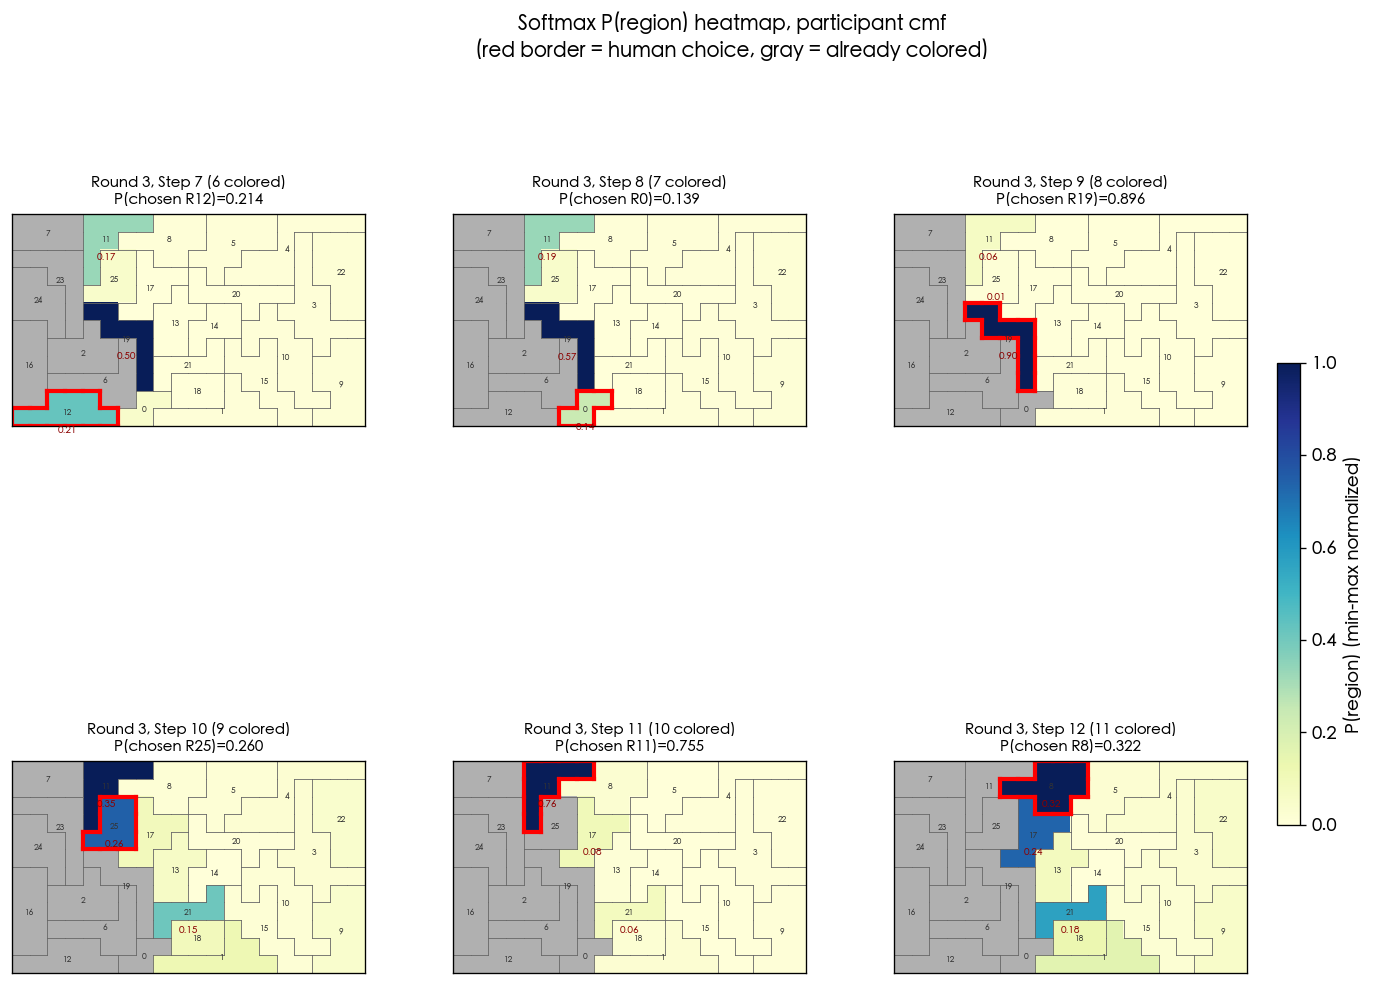

In [90]:
# 选取第一个被试, Round 3 的中间 6 步绘制热力图（有更多已着色区域，对比更明显）
target_result = all_results[2]
target_round = '3'
params = np.array([target_result['beta_n'], target_result['beta_d']])

# 重新构建 fitting steps
actions = parse_csv(target_result['filepath'])
fitting_steps = build_fitting_steps(actions, maps)

# 筛选指定 round 的步骤，跳过前几步（选中间段更有区分度）
round_steps = [s for s in fitting_steps if s['round'] == target_round]
start_idx = max(0, len(round_steps) // 4)  # 从 1/4 处开始
show_steps = round_steps[start_idx:start_idx + 6]

# 获取 grid
rng = mulberry32(ROUND_SEEDS[int(target_round) - 1])
grid, regions, adjacency = generate_map(ROUND_SIZES[int(target_round) - 1], rng)

n_show = len(show_steps)
fig, axes = plt.subplots(2, 3, figsize=(16, 10),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.25})
axes = axes.flatten()

for i, step in enumerate(show_steps):
    n_colored = sum(1 for c in step['current_colors'] if c is not None)
    draw_softmax_heatmap(axes[i], grid, regions, step, params,
                         title=f'Round {target_round}, Step {start_idx+i+1} ({n_colored} colored)')

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

# colorbar 放在右侧，不挤压子图
sm = cm.ScalarMappable(cmap=cm.YlGnBu, norm=Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes.tolist(), shrink=0.5, pad=0.02,
             label='P(region) (min-max normalized)')

fig.suptitle(f'Softmax P(region) heatmap, participant {target_result["name"]}\n'
             f'(red border = human choice, gray = already colored)',
             fontsize=12, fontweight='bold', y=0.98)
plt.show()

## 7. 图5: 人类 vs Agent 选择序列对比

选取一个 round，在两个 grid 上分别标注 agent 和人类的选择顺序编号。

In [91]:
def agent_solve(regions, adjacency, colors):
    """Agent 求解策略 (与 agent_visualization 一致)。"""
    n = len(regions)
    current_colors = [None] * n
    steps = []
    for step_num in range(1, n + 1):
        uncolored = [i for i in range(n) if current_colors[i] is None]
        if not uncolored:
            break
        def sort_key(rid):
            colored_nbrs = sum(1 for nb in adjacency[rid] if current_colors[nb] is not None)
            return (-colored_nbrs, centroid_distance(regions[rid]))
        uncolored.sort(key=sort_key)
        chosen = uncolored[0]
        used = {current_colors[nb] for nb in adjacency[chosen] if current_colors[nb] is not None}
        color = next((c for c in colors if c not in used), colors[0])
        steps.append({'step': step_num, 'region': chosen, 'color': color})
        current_colors[chosen] = color
    return steps, current_colors


def draw_order_grid(ax, grid, regions, region_order, region_colors, title=''):
    """绘制带选择顺序编号的 grid。"""
    img = np.zeros((ROWS, COLS, 4))
    for r in range(ROWS):
        for c in range(COLS):
            rid = grid[r][c]
            color = region_colors.get(rid, UNCOLORED)
            img[r, c] = to_rgba(color)
    ax.imshow(img, interpolation='nearest', aspect='equal')
    draw_grid_base(ax, grid, regions)

    # 标注顺序编号
    for rid, order_num in region_order.items():
        cells = regions[rid]
        avg_r = sum(r for r, c in cells) / len(cells)
        avg_c = sum(c for r, c in cells) / len(cells)
        ax.text(avg_c, avg_r, str(order_num), ha='center', va='center',
                fontsize=7, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title(title, fontsize=11)

print('对比函数定义完成')

对比函数定义完成


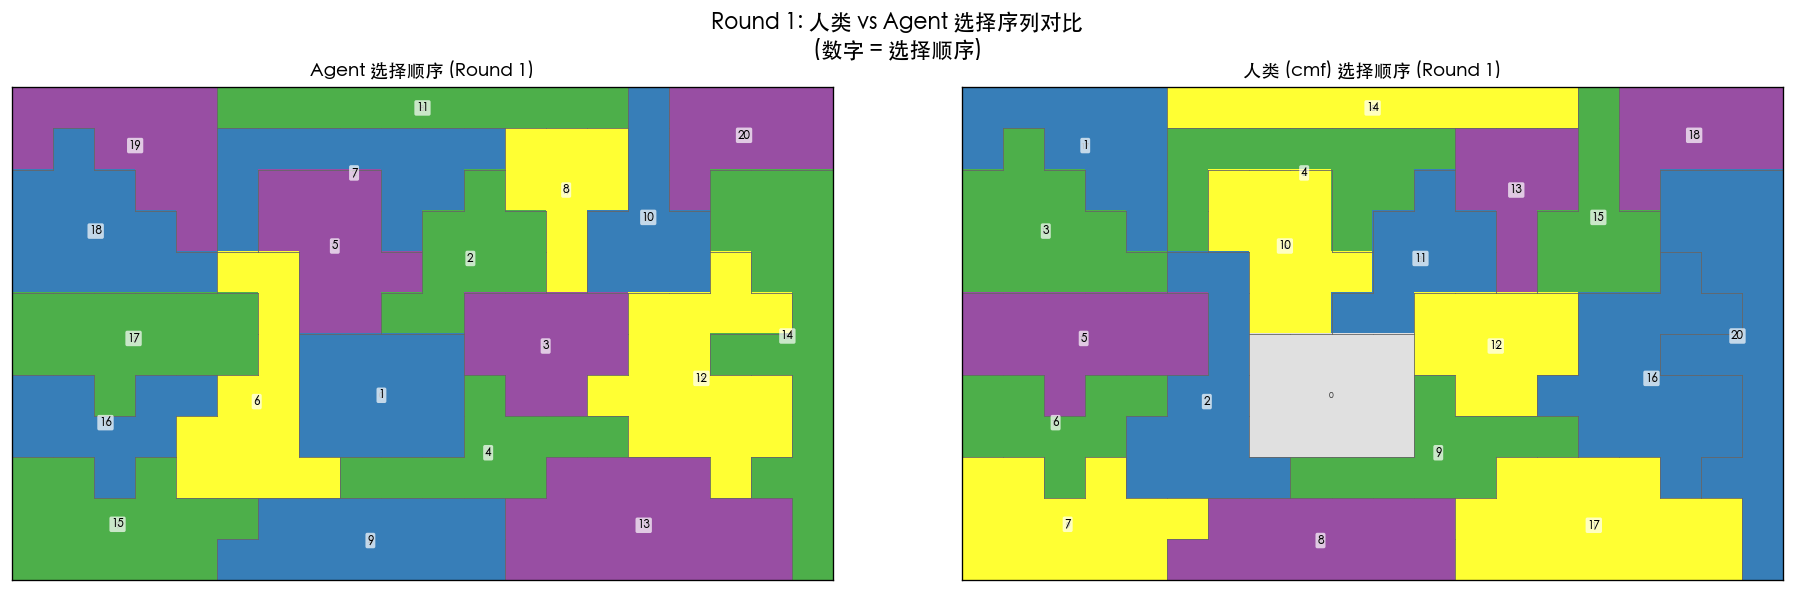

In [92]:
# 选取第一个被试, Round 1
compare_round = '1'
compare_result = all_results[2]
rnd_idx = int(compare_round) - 1

# 生成地图
rng = mulberry32(ROUND_SEEDS[rnd_idx])
grid, regions, adjacency = generate_map(ROUND_SIZES[rnd_idx], rng)

# Agent 求解
agent_steps, agent_final = agent_solve(regions, adjacency, COLORS)
agent_order = {s['region']: s['step'] for s in agent_steps}
agent_colors = {s['region']: s['color'] for s in agent_steps}

# 人类选择序列 (从 fitting steps 提取)
actions = parse_csv(compare_result['filepath'])
human_steps = build_fitting_steps(actions, maps)
human_round_steps = [s for s in human_steps if s['round'] == compare_round]

human_order = {}
human_colors_map = {}
for i, s in enumerate(human_round_steps):
    rid = s['chosen_region']
    if rid not in human_order:  # 只记录第一次着色
        human_order[rid] = i + 1
        human_colors_map[rid] = COLORS[s['chosen_color']]

# 绘制对比图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

draw_order_grid(ax1, grid, regions, agent_order, agent_colors,
                title=f'Agent 选择顺序 (Round {compare_round})')
draw_order_grid(ax2, grid, regions, human_order, human_colors_map,
                title=f'人类 ({compare_result["name"]}) 选择顺序 (Round {compare_round})')

fig.suptitle(f'Round {compare_round}: 人类 vs Agent 选择序列对比\n(数字 = 选择顺序)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()